## 6 — Lexicon Baselines (VA prediction)

## Inputs
- `data/processed/4-writestreak_posts_highgap_with_mh_embedding.csv` 
- `data/raw/lexicons/NRC-VAD-Lexicon-v2.1.txt`
- `data/processed/1-imbault_gaps_va.csv` 

## Outputs
Saved to:
- `data\processed\6_lexicon_affect.csv`

In [72]:
from __future__ import annotations

from collections import defaultdict
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()

# Try to use config if available; otherwise fall back to default folders.
processed_dir = REPO_ROOT / ".." / "data" / "processed"
tables_dir = REPO_ROOT / ".." / "reports" / "tables"
figures_dir = REPO_ROOT / ".." / "reports" / "figures"
raw_dir = REPO_ROOT / ".." / "data" / "raw"

try:
    import sys
    sys.path.insert(0, str(REPO_ROOT / ".." / "src"))
    from l2affect.utils.config import load_config, resolve  # type: ignore

    cfg = load_config(REPO_ROOT / ".." / "configs" / "config.yaml")
    processed_dir = resolve(cfg["paths"]["processed_dir"])
    tables_dir = resolve(cfg["paths"]["reports_tables_dir"])
    figures_dir = resolve(cfg["paths"]["reports_figures_dir"])
    raw_dir = resolve(cfg["paths"]["raw_dir"])
except Exception as e:
    print("Config not loaded (ok). Using default folders.")
    print("Reason:", e)

processed_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
raw_dir.mkdir(parents=True, exist_ok=True)

processed_dir, tables_dir, figures_dir, raw_dir

(WindowsPath('C:/Users/hus44/Code/Directed-Reading-Project/data/processed'),
 WindowsPath('C:/Users/hus44/Code/Directed-Reading-Project/reports/tables'),
 WindowsPath('C:/Users/hus44/Code/Directed-Reading-Project/reports/figures'),
 WindowsPath('C:/Users/hus44/Code/Directed-Reading-Project/data/raw'))

In [73]:
posts_path = processed_dir / "4-writestreak_posts_highgap_with_mh_embedding.csv"
imbault_path = processed_dir / "1-imbault_gaps_va.csv"
nrc_txt_path = raw_dir / "lexicons" / "NRC-VAD-Lexicon-v2.1" / "NRC-VAD-Lexicon-v2.1.txt"
out_path = processed_dir / "6_lexicon_affect.csv"
summary_path = processed_dir / "6_lexicon_affect_summary.csv"

Tokenization helper

In [74]:
TOKEN_RE = re.compile(r"[A-Za-z']+")

def ensure_text_tokens(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "text" not in df.columns:
        title = df.get("title", pd.Series([""] * len(df))).fillna("").astype(str).str.strip()
        body = df.get("selftext", pd.Series([""] * len(df))).fillna("").astype(str).str.strip()
        df["text"] = np.where(title.ne(""), (title + "\n\n" + body).str.strip(), body)

    def tokenize_text(text):
        return TOKEN_RE.findall(str(text).lower())

    if "tokens" not in df.columns or df["tokens"].isna().all():
        tokens_list = df["text"].fillna("").astype(str).map(tokenize_text)
    else:
        def parse_tokens(x):
            if isinstance(x, list):
                return [str(t).lower() for t in x]
            if not isinstance(x, str) or not x.strip():
                return []
            try:
                val = json.loads(x)
                if isinstance(val, list):
                    return [str(t).lower() for t in val]
            except Exception:
                pass
            return tokenize_text(x)

        tokens_list = df["tokens"].map(parse_tokens)

    df["tokens_list"] = tokens_list
    df["tokens"] = tokens_list.map(json.dumps)

    if "n_tokens" not in df.columns:
        df["n_tokens"] = tokens_list.map(len)

    return df

Load posts and imbault lexicon

In [75]:
posts = pd.read_csv(posts_path)
posts = ensure_text_tokens(posts)

print(posts.shape)

imb = pd.read_csv(imbault_path)
imb.head()

(9168, 39)


,word,valence_l1,arousal_l1,valence_l2,arousal_l2,gap_valence,gap_arousal,gap_mag
0,abandon,2.84,3.73,2.43,3.58,-0.41,-0.15,0.436578
1,abdomen,5.43,3.68,4.88,4.62,-0.55,0.94,1.089082
2,abduction,2.05,5.33,2.91,5.39,0.86,0.06,0.862090
3,ability,7.00,4.85,7.33,5.29,0.33,0.44,0.550000
4,absence,3.86,4.30,3.42,3.72,-0.44,-0.58,0.728011


Load NRC VAD v2 and normalize it to the same scale as Imbault's lexicon

In [76]:
def load_nrc_vad(txt_path: Path) -> pd.DataFrame:
    if not txt_path.exists():
        raise FileNotFoundError(f"NRC file not found: {txt_path}")

    nrc = pd.read_csv(txt_path, sep="\t")
    nrc.columns = [c.strip().lower() for c in nrc.columns]

    if "term" not in nrc.columns and "word" in nrc.columns:
        nrc = nrc.rename(columns={"word": "term"})

    required = {"term", "valence", "arousal"}
    missing = required - set(nrc.columns)
    if missing:
        raise ValueError(f"NRC lexicon missing columns: {missing}. Found: {list(nrc.columns)}")

    nrc["term"] = nrc["term"].astype(str).str.strip().str.lower()
    nrc["valence"] = pd.to_numeric(nrc["valence"], errors="coerce")
    nrc["arousal"] = pd.to_numeric(nrc["arousal"], errors="coerce")

    nrc = nrc.dropna(subset=["term", "valence", "arousal"]).copy()

    # rescale from [-1, 1] to [1, 9]
    nrc["valence"] = 4 * nrc["valence"] + 5
    nrc["arousal"] = 4 * nrc["arousal"] + 5

    # safety clipping
    nrc["valence"] = nrc["valence"].clip(1, 9)
    nrc["arousal"] = nrc["arousal"].clip(1, 9)

    return nrc[["term", "valence", "arousal"]]

nrc_l1 = load_nrc_vad(nrc_txt_path)

print(nrc_l1.shape)
print(nrc_l1[["valence", "arousal"]].describe())
nrc_l1.head()

(54800, 3)
            valence       arousal
count  54800.000000  54800.000000
mean       4.994551      5.073679
std        1.906436      1.855457
min        1.000000      1.000000
25%        3.664000      3.838000
50%        5.000000      5.000000
75%        6.332000      6.448000
max        9.000000      9.000000


,term,valence,arousal
0,a battery,5.536,3.808
1,a bit,4.616,3.944
2,a bunch,5.352,3.600
3,a cappella,5.536,4.536
4,a couple,6.064,4.560


Build unigram + multiword lexicon maps

In [77]:
def build_lexicon_maps_NRC(lex_df: pd.DataFrame):
    lex_df = lex_df.copy()
    lex_df["term"] = lex_df["term"].astype(str).str.strip().str.lower()

    uni = lex_df[~lex_df["term"].str.contains(r"\s+", regex=True)].copy()
    mwe = lex_df[lex_df["term"].str.contains(r"\s+", regex=True)].copy()

    unigram_map = {
        row.term: (float(row.valence), float(row.arousal))
        for row in uni.itertuples(index=False)
    }

    mwe_by_len = defaultdict(dict)
    for row in mwe.itertuples(index=False):
        toks = tuple(row.term.split())
        mwe_by_len[len(toks)][toks] = (float(row.valence), float(row.arousal))

    mwe_lengths = sorted(mwe_by_len.keys(), reverse=True)
    return unigram_map, mwe_by_len, mwe_lengths

def build_lexicon_maps_imb_l1(lex_df: pd.DataFrame):
    lex_df = lex_df.copy()
    lex_df["word"] = lex_df["word"].astype(str).str.strip().str.lower()

    uni = lex_df[~lex_df["word"].str.contains(r"\s+", regex=True)].copy()
    mwe = lex_df[lex_df["word"].str.contains(r"\s+", regex=True)].copy()

    unigram_map = {
        row.word: (float(row.valence_l1), float(row.arousal_l1))
        for row in uni.itertuples(index=False)
    }

    mwe_by_len = defaultdict(dict)
    for row in mwe.itertuples(index=False):
        toks = tuple(row.word.split())
        mwe_by_len[len(toks)][toks] = (float(row.valence_l1), float(row.arousal_l1))

    mwe_lengths = sorted(mwe_by_len.keys(), reverse=True)
    return unigram_map, mwe_by_len, mwe_lengths

def build_lexicon_maps_imb_l2(lex_df: pd.DataFrame):
    lex_df = lex_df.copy()
    lex_df["word"] = lex_df["word"].astype(str).str.strip().str.lower()

    uni = lex_df[~lex_df["word"].str.contains(r"\s+", regex=True)].copy()
    mwe = lex_df[lex_df["word"].str.contains(r"\s+", regex=True)].copy()

    unigram_map = {
        row.word: (float(row.valence_l2), float(row.arousal_l2))
        for row in uni.itertuples(index=False)
    }

    mwe_by_len = defaultdict(dict)
    for row in mwe.itertuples(index=False):
        toks = tuple(row.word.split())
        mwe_by_len[len(toks)][toks] = (float(row.valence_l2), float(row.arousal_l2))

    mwe_lengths = sorted(mwe_by_len.keys(), reverse=True)
    return unigram_map, mwe_by_len, mwe_lengths

nrc_uni, nrc_mwe, nrc_mwe_lens = build_lexicon_maps_NRC(nrc_l1)
imb_l1_uni, imb_l1_mwe, imb_l1_mwe_lens = build_lexicon_maps_imb_l1(imb)
imb_l2_uni, imb_l2_mwe, imb_l2_mwe_lens = build_lexicon_maps_imb_l2(imb)

print("NRC unigrams:", len(nrc_uni))
print("NRC MWE lengths:", nrc_mwe_lens)

print("Imbault L1 unigrams:", len(imb_l1_uni))
print("Imbault L1 MWE lengths:", imb_l1_mwe_lens)

print("Imbault L2 unigrams:", len(imb_l2_uni))
print("Imbault L2 MWE lengths:", imb_l2_mwe_lens)

NRC unigrams: 44727
NRC MWE lengths: [3, 2]
Imbault L1 unigrams: 2008
Imbault L1 MWE lengths: []
Imbault L2 unigrams: 2008
Imbault L2 MWE lengths: []


Scoring  for reddit posts

In [78]:
def score_tokens_with_lexicon(tokens, unigram_map, mwe_by_len, mwe_lengths):
    toks = [str(t).lower() for t in tokens]
    n_tokens = len(toks)

    hits = []
    i = 0
    while i < n_tokens:
        matched = False

        for L in mwe_lengths:
            if i + L <= n_tokens:
                phrase = tuple(toks[i:i+L])
                if phrase in mwe_by_len[L]:
                    val, aro = mwe_by_len[L][phrase]
                    hits.append({
                        "term": " ".join(phrase),
                        "valence": val,
                        "arousal": aro,
                        "span_len": L,
                        "match_type": "mwe",
                    })
                    i += L
                    matched = True
                    break

        if matched:
            continue

        tok = toks[i]
        if tok in unigram_map:
            val, aro = unigram_map[tok]
            hits.append({
                "term": tok,
                "valence": val,
                "arousal": aro,
                "span_len": 1,
                "match_type": "unigram",
            })

        i += 1

    if not hits:
        return {
            "expected_valence": np.nan,
            "expected_arousal": np.nan,
            "matched_items": 0,
            "matched_token_count": 0,
            "matched_token_prop": 0.0,
            "matched_terms": json.dumps([]),
        }

    vals = [h["valence"] for h in hits]
    aros = [h["arousal"] for h in hits]
    matched_token_count = int(sum(h["span_len"] for h in hits))

    return {
        "expected_valence": float(np.mean(vals)),
        "expected_arousal": float(np.mean(aros)),
        "matched_items": int(len(hits)),
        "matched_token_count": matched_token_count,
        "matched_token_prop": float(matched_token_count / max(1, n_tokens)),
        "matched_terms": json.dumps([h["term"] for h in hits[:100]]),
    }

Decide here whether to use NRC or Imbault for L1

In [79]:
l1_scores_NRC = pd.DataFrame(
    posts["tokens_list"].map(
        lambda x: score_tokens_with_lexicon(x, nrc_uni, nrc_mwe, nrc_mwe_lens)
    ).tolist()
).add_prefix("l1_")

l1_scores_imbault = pd.DataFrame(
    posts["tokens_list"].map(
        lambda x: score_tokens_with_lexicon(x, imb_l1_uni, imb_l1_mwe, imb_l1_mwe_lens)
    ).tolist()
).add_prefix("l1_")

l2_scores_imbault = pd.DataFrame(
    posts["tokens_list"].map(
        lambda x: score_tokens_with_lexicon(x, imb_l2_uni, imb_l2_mwe, imb_l2_mwe_lens)
    ).tolist()
).add_prefix("l2_")

# Comment or uncomment the below to choose which lexicon to use

# NRC
# vad_posts = posts.join(l1_scores_NRC).join(l2_scores_imbault)

# Imbault
vad_posts = posts.join(l1_scores_imbault).join(l2_scores_imbault)

vad_posts["expected_gap_valence"] = (
    vad_posts["l2_expected_valence"] - vad_posts["l1_expected_valence"]
)

vad_posts["expected_gap_arousal"] = (
    vad_posts["l2_expected_arousal"] - vad_posts["l1_expected_arousal"]
)

vad_posts["expected_gap_mag"] = np.sqrt(
    vad_posts["expected_gap_valence"] ** 2 +
    vad_posts["expected_gap_arousal"] ** 2
)

vad_posts["both_lexicons_matched"] = (
    vad_posts["l1_matched_items"].gt(0) &
    vad_posts["l2_matched_items"].gt(0)
).astype(int)

print(vad_posts.shape)
vad_posts[[
    "l1_expected_valence",
    "l2_expected_valence",
    "expected_gap_valence",
    "l1_matched_items",
    "l2_matched_items"
]].head()

(9168, 55)


,l1_expected_valence,l2_expected_valence,expected_gap_valence,l1_matched_items,l2_matched_items
0,5.997500,5.455000,-0.542500,4,4
1,5.778889,5.526667,-0.252222,9,9
2,6.800000,7.146667,0.346667,3,3
3,5.616207,5.477241,-0.138966,29,29
4,7.400000,7.476667,0.076667,3,3


Summary table

In [80]:
summary = {
    "posts_n": int(len(vad_posts)),
    "users_n": int(vad_posts["user_id"].nunique()) if "user_id" in vad_posts.columns else np.nan,

    "l1_posts_with_any_match": int(vad_posts["l1_matched_items"].gt(0).sum()),
    "l2_posts_with_any_match": int(vad_posts["l2_matched_items"].gt(0).sum()),
    "posts_with_both_lexicons_matched": int(vad_posts["both_lexicons_matched"].sum()),

    "l1_match_rate_mean": float(vad_posts["l1_matched_token_prop"].mean()),
    "l2_match_rate_mean": float(vad_posts["l2_matched_token_prop"].mean()),

    "l1_expected_valence_mean": float(vad_posts["l1_expected_valence"].mean()),
    "l1_expected_arousal_mean": float(vad_posts["l1_expected_arousal"].mean()),
    "l2_expected_valence_mean": float(vad_posts["l2_expected_valence"].mean()),
    "l2_expected_arousal_mean": float(vad_posts["l2_expected_arousal"].mean()),

    "expected_gap_valence_mean": float(vad_posts["expected_gap_valence"].mean()),
    "expected_gap_arousal_mean": float(vad_posts["expected_gap_arousal"].mean()),
    "expected_gap_mag_mean": float(vad_posts["expected_gap_mag"].mean()),
}

summary_df = pd.DataFrame(list(summary.items()), columns=["metric", "value"])


diagnostics_df = pd.DataFrame({
    "metric": [
        "l1_expected_valence_min",
        "l1_expected_valence_max",
        "l2_expected_valence_min",
        "l2_expected_valence_max",
        "l1_expected_arousal_min",
        "l1_expected_arousal_max",
        "l2_expected_arousal_min",
        "l2_expected_arousal_max",
        "expected_gap_valence_min",
        "expected_gap_valence_max",
        "expected_gap_arousal_min",
        "expected_gap_arousal_max",
    ],
    "value": [
        vad_posts["l1_expected_valence"].min(),
        vad_posts["l1_expected_valence"].max(),
        vad_posts["l2_expected_valence"].min(),
        vad_posts["l2_expected_valence"].max(),
        vad_posts["l1_expected_arousal"].min(),
        vad_posts["l1_expected_arousal"].max(),
        vad_posts["l2_expected_arousal"].min(),
        vad_posts["l2_expected_arousal"].max(),
        vad_posts["expected_gap_valence"].min(),
        vad_posts["expected_gap_valence"].max(),
        vad_posts["expected_gap_arousal"].min(),
        vad_posts["expected_gap_arousal"].max(),
    ]
})

summary_df

,metric,value
0,posts_n,9168.000000
1,users_n,704.000000
2,l1_posts_with_any_match,9168.000000
3,l2_posts_with_any_match,9168.000000
4,posts_with_both_lexicons_matched,9168.000000
5,l1_match_rate_mean,0.082560
6,l2_match_rate_mean,0.082560
7,l1_expected_valence_mean,6.067740
8,l1_expected_arousal_mean,4.053303
9,l2_expected_valence_mean,5.841217


In [81]:
vad_posts.to_csv(out_path, index=False)
summary_df.to_csv(summary_path, index=False)

print("Wrote:", out_path)
print("Wrote:", summary_path)

Wrote: C:\Users\hus44\Code\Directed-Reading-Project\data\processed\6_lexicon_affect.csv
Wrote: C:\Users\hus44\Code\Directed-Reading-Project\data\processed\6_lexicon_affect_summary.csv


Diagnostic plots

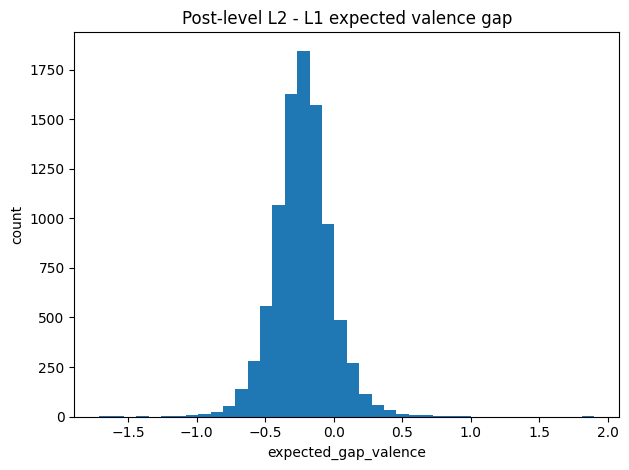

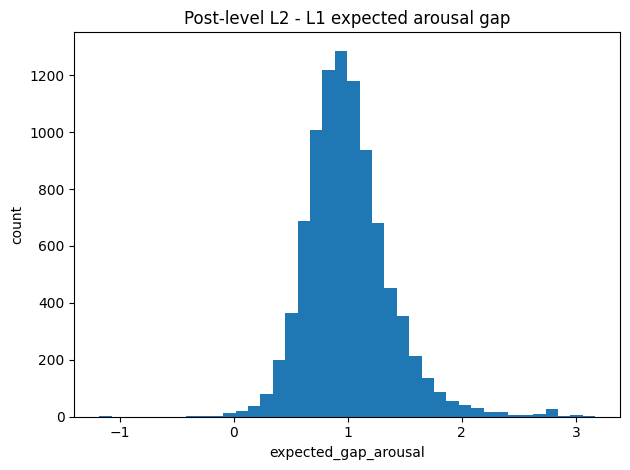

In [82]:
plt.figure()
plt.hist(vad_posts["expected_gap_valence"].dropna(), bins=40)
plt.title("Post-level L2 - L1 expected valence gap")
plt.xlabel("expected_gap_valence")
plt.ylabel("count")
plt.tight_layout()
plt.show()

plt.figure()
plt.hist(vad_posts["expected_gap_arousal"].dropna(), bins=40)
plt.title("Post-level L2 - L1 expected arousal gap")
plt.xlabel("expected_gap_arousal")
plt.ylabel("count")
plt.tight_layout()
plt.show()

In [83]:
cols_to_show = [
    "user_id",
    "post_index",
    "n_tokens",
    "l1_expected_valence",
    "l1_expected_arousal",
    "l2_expected_valence",
    "l2_expected_arousal",
    "expected_gap_valence",
    "expected_gap_arousal",
    "expected_gap_mag",
    "l1_matched_items",
    "l2_matched_items",
    "l1_matched_token_prop",
    "l2_matched_token_prop",
    "l1_matched_terms",
    "l2_matched_terms",
    "text",
]

existing_cols = [c for c in cols_to_show if c in vad_posts.columns]

vad_posts.sort_values("expected_gap_mag", ascending=False)[existing_cols].head(5)

,user_id,post_index,n_tokens,l1_expected_valence,l1_expected_arousal,l2_expected_valence,l2_expected_arousal,expected_gap_valence,expected_gap_arousal,expected_gap_mag,l1_matched_items,l2_matched_items,l1_matched_token_prop,l2_matched_token_prop,l1_matched_terms,l2_matched_terms,text
4727,8ee5ec6aec715238,7,54,6.67,2.35,7.57,5.49,0.90,3.14,3.266435,1,1,0.018519,0.018519,"[""fresh""]","[""fresh""]",Streak 7: I want to cry when I write German\n\...
4480,8534fc1e1ac28448,10,5,7.50,3.48,7.00,6.65,-0.50,3.17,3.209190,1,1,0.200000,0.200000,"[""special""]","[""special""]","Streak 10. Break\n\nNothing special, today"
5008,9c533b197c8ca071,189,30,7.27,3.52,6.85,6.56,-0.42,3.04,3.068876,1,1,0.033333,0.033333,"[""story""]","[""story""]",Streak 209\n\nA movie that a long time was on ...
8220,dd5f43ed535f74eb,128,5,7.27,3.52,6.85,6.56,-0.42,3.04,3.068876,1,1,0.200000,0.200000,"[""story""]","[""story""]",Streak 1: Story about today\n\n[deleted]
8211,dd5f43ed535f74eb,50,4,7.27,3.52,6.85,6.56,-0.42,3.04,3.068876,1,1,0.250000,0.250000,"[""story""]","[""story""]",Streak 17: Story time\n\n[deleted]


Checks whether posts containing high-gap words have larger expected_gap_mag than posts without them

In [84]:
from scipy.stats import mannwhitneyu

high_gap_words_path = processed_dir / "top30_highgap_words_mh_enriched_top5.csv"

high_gap_df = pd.read_csv(high_gap_words_path)
high_gap_words = set(
    high_gap_df["word"].dropna().astype(str).str.strip().str.lower()
)

def contains_high_gap_word(tokens, high_gap_words):
    toks = [str(t).lower() for t in tokens]
    return int(any(t in high_gap_words for t in toks))

vad_posts["has_high_gap_word"] = vad_posts["tokens_list"].map(
    lambda toks: contains_high_gap_word(toks, high_gap_words)
)

with_high_gap = vad_posts.loc[
    vad_posts["has_high_gap_word"] == 1, "expected_gap_mag"
].dropna()

without_high_gap = vad_posts.loc[
    vad_posts["has_high_gap_word"] == 0, "expected_gap_mag"
].dropna()

u_stat, p_value = mannwhitneyu(
    with_high_gap,
    without_high_gap,
    alternative="two-sided"
)

comparison_df = pd.DataFrame({
    "group": ["contains_high_gap_word", "does_not_contain_high_gap_word"],
    "n_posts": [len(with_high_gap), len(without_high_gap)],
    "mean_expected_gap_mag": [with_high_gap.mean(), without_high_gap.mean()],
    "median_expected_gap_mag": [with_high_gap.median(), without_high_gap.median()],
    "std_expected_gap_mag": [with_high_gap.std(), without_high_gap.std()],
})

display(comparison_df)

print(f"Mann-Whitney U statistic: {u_stat:.3f}")
print(f"p-value: {p_value:.6g}")

,group,n_posts,mean_expected_gap_mag,median_expected_gap_mag,std_expected_gap_mag
0,contains_high_gap_word,6482,1.07660,1.030333,0.351859
1,does_not_contain_high_gap_word,2686,1.00347,0.956471,0.350947


Mann-Whitney U statistic: 9867227.500
p-value: 7.21713e-24
